# Car Insurance Classification

A supervised learning notebook for predicting car-insurance purchase decisions using feature engineering, missing-value handling, model pipelines, feature selection, and tuned classifiers.


## Cell 1 – Import libraries and load data

Import all required libraries and load the original `carInsurance_train.csv` file.
This gives us the raw data structure (rows, columns, dtypes) before any cleaning.


In [46]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# === Load dataset ===
# Update this path to where your CSV is stored on your machine
file_path = r"data/carInsurance_train.csv"

df = pd.read_csv(file_path)

print("Shape of RAW data:", df.shape)
display(df.head())
df.info()


Shape of RAW data: (4000, 19)


,Id,Age,Job,Marital,Education,Default,Balance,HHInsurance,CarLoan,Communication,LastContactDay,LastContactMonth,NoOfContacts,DaysPassed,PrevAttempts,Outcome,CallStart,CallEnd,CarInsurance
0,1,32,management,single,tertiary,0,1218,1,0,telephone,28,jan,2,-1,0,NaN,13:45:20,13:46:30,0
1,2,32,blue-collar,married,primary,0,1156,1,0,NaN,26,may,5,-1,0,NaN,14:49:03,14:52:08,0
2,3,29,management,single,tertiary,0,637,1,0,cellular,3,jun,1,119,1,failure,16:30:24,16:36:04,1
3,4,25,student,single,primary,0,373,1,0,cellular,11,may,2,-1,0,NaN,12:06:43,12:20:22,1
4,5,30,management,married,tertiary,0,2694,0,0,cellular,3,jun,1,-1,0,NaN,14:35:44,14:38:56,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                4000 non-null   int64 
 1   Age               4000 non-null   int64 
 2   Job               3981 non-null   object
 3   Marital           4000 non-null   object
 4   Education         3831 non-null   object
 5   Default           4000 non-null   int64 
 6   Balance           4000 non-null   int64 
 7   HHInsurance       4000 non-null   int64 
 8   CarLoan           4000 non-null   int64 
 9   Communication     3098 non-null   object
 10  LastContactDay    4000 non-null   int64 
 11  LastContactMonth  4000 non-null   object
 12  NoOfContacts      4000 non-null   int64 
 13  DaysPassed        4000 non-null   int64 
 14  PrevAttempts      4000 non-null   int64 
 15  Outcome           958 non-null    object
 16  CallStart         4000 non-null   object
 17  CallEnd       

## Cell 2 – Data cleaning and basic feature engineering

Create a cleaned copy of the data: remove duplicates, convert artificial null strings to real NaNs, engineer call duration and hour features, handle `DaysPassed = -1`, and clip numeric outliers.


In [47]:
# Make a working copy
df_clean = df.copy()

# 1) Drop exact duplicate rows (if any)
n_duplicates = df_clean.duplicated().sum()
print(f"Number of exact duplicate rows: {n_duplicates}")
df_clean = df_clean.drop_duplicates()
print("Shape after dropping duplicates:", df_clean.shape)

# 2) Convert artificial-null tokens in object columns to real NaN (in case they exist)
artificial_null_tokens = ["NA", "N/A", "na", "?", "unknown", "Unknown",
                          "none", "None", "null", "Null", ""]

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].replace(artificial_null_tokens, np.nan)

# 3) Time features: convert CallStart/CallEnd to duration + hour features
for col in ["CallStart", "CallEnd"]:
    df_clean[col] = pd.to_datetime(df_clean[col], format="%H:%M:%S", errors="coerce")

df_clean["CallDurationSeconds"] = (df_clean["CallEnd"] - df_clean["CallStart"]).dt.total_seconds()
df_clean["CallStartHour"] = df_clean["CallStart"].dt.hour
df_clean["CallEndHour"] = df_clean["CallEnd"].dt.hour

# Fix obviously wrong/negative durations (if any)
df_clean.loc[df_clean["CallDurationSeconds"] <= 0, "CallDurationSeconds"] = np.nan

# Drop raw time strings now that we've extracted useful numeric features
df_clean = df_clean.drop(columns=["CallStart", "CallEnd"])

# 4) Handle special value in DaysPassed: -1 means "no previous contact"
df_clean["NoPrevContact"] = (df_clean["DaysPassed"] == -1).astype(int)
df_clean["DaysPassed"] = df_clean["DaysPassed"].replace(-1, np.nan)

# 5) Simple outlier handling: clip numeric features to [1st, 99th] percentiles
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Do NOT touch Id or CarInsurance
numeric_cols_for_outliers = [c for c in numeric_cols if c not in ["Id", "CarInsurance"]]

for col in numeric_cols_for_outliers:
    q01 = df_clean[col].quantile(0.01)
    q99 = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(q01, q99)

print("Shape after cleaning & feature engineering:", df_clean.shape)
display(df_clean.head())


Number of exact duplicate rows: 0
Shape after dropping duplicates: (4000, 19)
Shape after cleaning & feature engineering: (4000, 21)


,Id,Age,Job,Marital,Education,Default,Balance,HHInsurance,CarLoan,Communication,...,LastContactMonth,NoOfContacts,DaysPassed,PrevAttempts,Outcome,CarInsurance,CallDurationSeconds,CallStartHour,CallEndHour,NoPrevContact
0,1,32,management,single,tertiary,0,1218.0,1,0,telephone,...,jan,2,NaN,0,NaN,0,70.0,13,13,1
1,2,32,blue-collar,married,primary,0,1156.0,1,0,NaN,...,may,5,NaN,0,NaN,0,185.0,14,14,1
2,3,29,management,single,tertiary,0,637.0,1,0,cellular,...,jun,1,119.0,1,failure,1,340.0,16,16,0
3,4,25,student,single,primary,0,373.0,1,0,cellular,...,may,2,NaN,0,NaN,1,819.0,12,12,1
4,5,30,management,married,tertiary,0,2694.0,0,0,cellular,...,jun,1,NaN,0,NaN,0,192.0,14,14,1


## Cell 3 – Identify numeric and categorical features

Identify numeric and categorical columns after cleaning and build a list of numeric columns to use in histograms (excluding `Id` and `CarInsurance`).
These lists are reused in the following visualizations.


In [36]:
# Numeric and categorical columns after cleaning
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_clean = df_clean.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns (cleaned):", numeric_cols_clean)
print("Categorical columns (cleaned):", categorical_cols_clean)

# Remove Id and target from numeric list for histograms
numeric_hist_cols = [c for c in numeric_cols_clean if c not in ["Id", "CarInsurance"]]


Numeric columns (cleaned): ['Id', 'Age', 'Default', 'Balance', 'HHInsurance', 'CarLoan', 'LastContactDay', 'NoOfContacts', 'DaysPassed', 'PrevAttempts', 'CarInsurance', 'CallDurationSeconds', 'CallStartHour', 'CallEndHour', 'NoPrevContact']
Categorical columns (cleaned): ['Job', 'Marital', 'Education', 'Communication', 'LastContactMonth', 'Outcome']


## Cell 4 – Target distribution plot

Plot the distribution of the target variable `CarInsurance` on the cleaned data.
This lets us check how balanced the classes (0 vs 1) are.


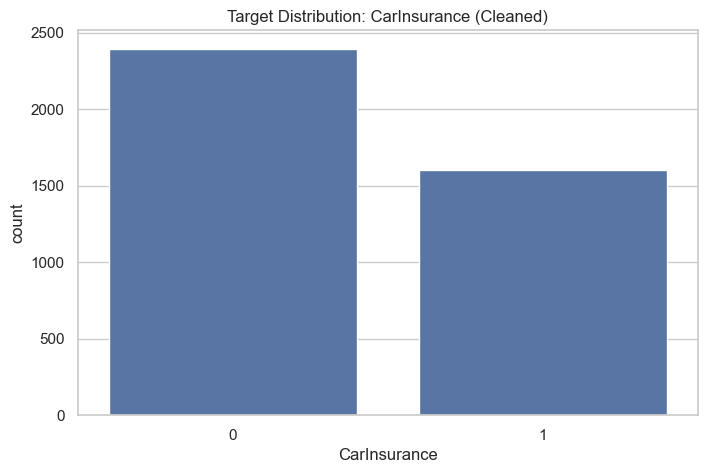

In [37]:
# Target distribution
plt.figure()
sns.countplot(x="CarInsurance", data=df_clean)
plt.title("Target Distribution: CarInsurance (Cleaned)")
plt.show()


## Cell 5 – Histograms of numeric features

Plot histograms for all selected numeric features.
This helps visualize the spread, skewness, and remaining outliers in the numeric variables.


In [38]:
# Histograms of numeric features
df_clean[numeric_hist_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle("Histograms of Numeric Features (Cleaned)", y=1.02)
plt.tight_layout()
plt.show()


## Cell 6 – Countplot of first categorical feature

Plot a countplot for the first categorical feature.
This shows how its categories are distributed in the cleaned dataset.


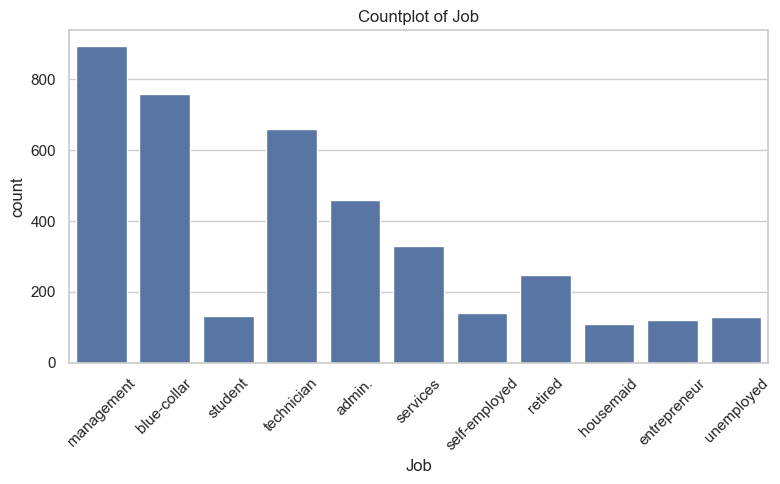

In [39]:
# Countplot for first categorical feature (if exists)
if len(categorical_cols_clean) > 0:
    col = categorical_cols_clean[0]
    plt.figure()
    sns.countplot(x=col, data=df_clean)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Cell 7 – Countplot of second categorical feature

Plot a countplot for the second categorical feature (if it exists).
Again, this helps understand the frequencies of each category.


In [40]:
# Countplot for second categorical feature
if len(categorical_cols_clean) > 1:
    col = categorical_cols_clean[1]
    plt.figure()
    sns.countplot(x=col, data=df_clean)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Cell 8 – Countplot of third categorical feature

Plot a countplot for the third categorical feature (if it exists).
We use separate cells so each plot is clearly separated in the notebook.


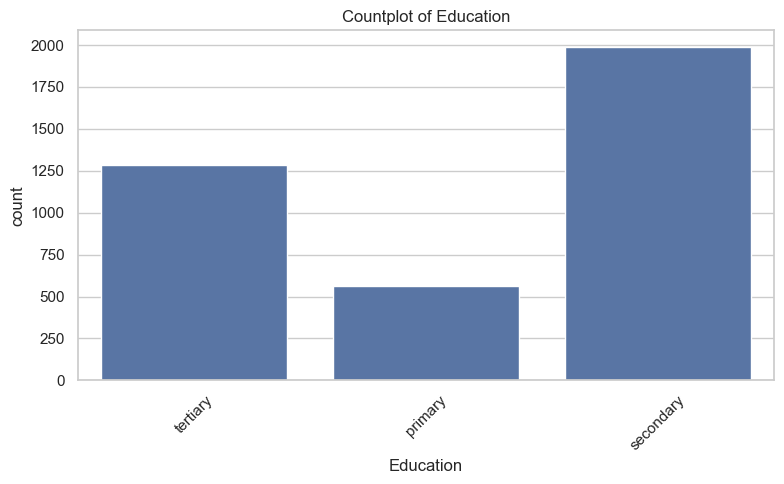

In [41]:
# Countplot for third categorical feature
if len(categorical_cols_clean) > 2: 
    col = categorical_cols_clean[2]
    plt.figure()
    sns.countplot(x=col, data=df_clean)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Cell 9 – Countplot of fourth categorical feature

Plot a countplot for the fourth categorical feature (if it exists).
This completes the basic view of the main categorical distributions.


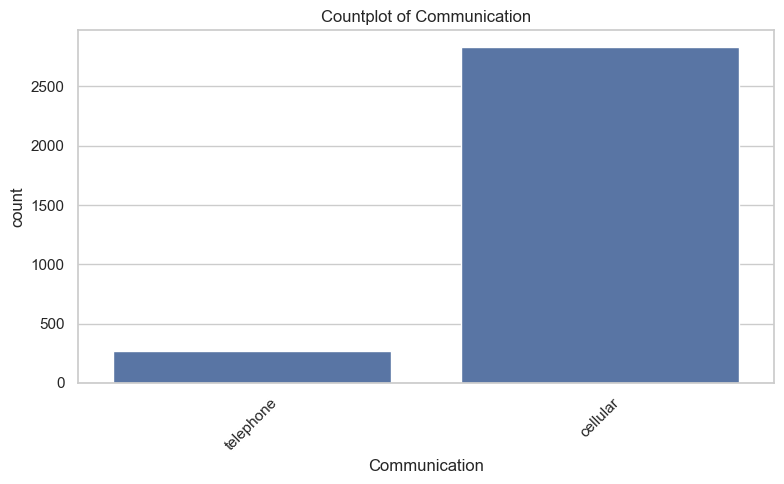

In [42]:
# Countplot for fourth categorical feature
if len(categorical_cols_clean) > 3:
    col = categorical_cols_clean[3]
    plt.figure()
    sns.countplot(x=col, data=df_clean)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Cell 10 – Correlation heatmap of numeric features

Plot a correlation heatmap for the numeric features plus the target.
This highlights linear relationships and potential multicollinearity between features.


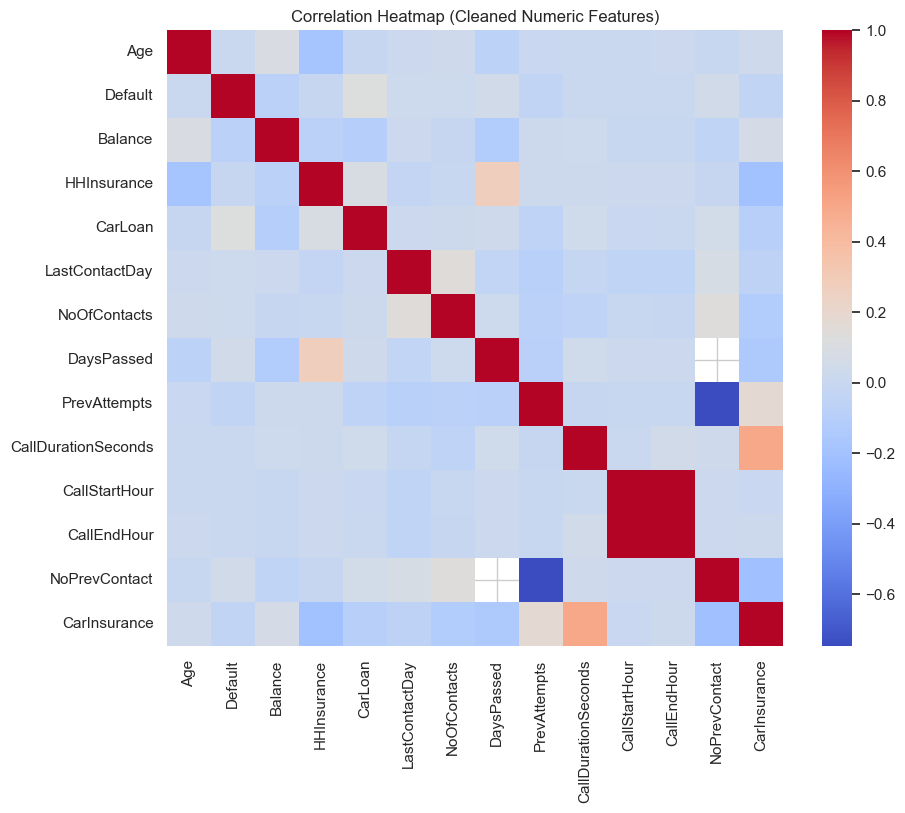

In [43]:
# Correlation heatmap (numeric)
plt.figure(figsize=(10, 8))
corr = df_clean[numeric_hist_cols + ["CarInsurance"]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Cleaned Numeric Features)")
plt.show()


## Cell 11 – Inject artificial missing values

Add artificial NaNs (5% per feature, excluding `Id` and `CarInsurance`) to simulate missing data.
This is part of the assignment and will later be handled by the preprocessing pipelines.


In [44]:
# Work on a copy that we will use for modeling
df_missing = df_clean.copy()

np.random.seed(42)  # reproducibility

# We add artificial NaNs to all columns except Id and target
cols_to_corrupt = [
    col for col in df_missing.columns
    if col not in ["Id", "CarInsurance"]
]

null_fraction = 0.05  # 5%

for col in cols_to_corrupt:
    n_rows = df_missing.shape[0]
    n_nulls = int(null_fraction * n_rows)
    null_indices = np.random.choice(df_missing.index, size=n_nulls, replace=False)
    df_missing.loc[null_indices, col] = np.nan

print("Null counts per column after artificial corruption:")
print(df_missing.isna().sum())


Null counts per column after artificial corruption:
Id                        0
Age                     200
Job                     218
Marital                 200
Education               362
Default                 200
Balance                 200
HHInsurance             200
CarLoan                 200
Communication          1052
LastContactDay          200
LastContactMonth        200
NoOfContacts            200
DaysPassed             3092
PrevAttempts            200
Outcome                3097
CarInsurance              0
CallDurationSeconds     200
CallStartHour           200
CallEndHour             200
NoPrevContact           200
dtype: int64


## Cell 12 – Train/test split and preprocessing setup

Split the data into training and test sets with stratification on the target.
Define a `ColumnTransformer` that imputes missing values, scales numeric features, and one-hot encodes categorical features, ready to be plugged into model pipelines.


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate features and target
X = df_missing.drop(columns=["CarInsurance", "Id"])
y = df_missing["CarInsurance"]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("\ny_test distribution:\n", y_test.value_counts(normalize=True))

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Numeric features: ['Age', 'Default', 'Balance', 'HHInsurance', 'CarLoan', 'LastContactDay', 'NoOfContacts', 'DaysPassed', 'PrevAttempts', 'CallDurationSeconds', 'CallStartHour', 'CallEndHour', 'NoPrevContact']
Categorical features: ['Job', 'Marital', 'Education', 'Communication', 'LastContactMonth', 'Outcome']
X_train shape: (3200, 19)
X_test shape : (800, 19)
y_train distribution:
 CarInsurance
0    0.599063
1    0.400938
Name: proportion, dtype: float64

y_test distribution:
 CarInsurance
0    0.59875
1    0.40125
Name: proportion, dtype: float64


## Cell 13 – Feature selection and hyperparameter tuning

Build pipelines for Logistic Regression, Decision Tree, and KNN that include preprocessing and `SelectKBest` feature selection.
Use `GridSearchCV` with stratified 5-fold CV and F1 scoring to find the best hyperparameters for each model.
The best tuned models are stored for later evaluation.


In [49]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Common cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === Logistic Regression pipeline ===
log_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=20)),  # feature selection
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_log = {
    "selector__k": [10, 20, "all"],        # how many best features to keep
    "clf__C": [0.1, 1.0, 10.0],            # regularization strength
    "clf__class_weight": [None, "balanced"]
}

log_grid = GridSearchCV(
    estimator=log_pipe,
    param_grid=param_grid_log,
    cv=cv,
    scoring="f1",      # focus on F1 to balance precision & recall (reduce false positives)
    n_jobs=-1
)

# === Decision Tree pipeline ===
dt_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=20)),
    ("clf", DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "selector__k": [10, 20, "all"],
    "clf__max_depth": [None, 5, 10, 15],
    "clf__min_samples_split": [2, 10],
    "clf__min_samples_leaf": [1, 5],
    "clf__class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid_dt,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

# === KNN pipeline ===
knn_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=20)),
    ("clf", KNeighborsClassifier())
])

param_grid_knn = {
    "selector__k": [10, 20, "all"],
    "clf__n_neighbors": [5, 9, 15],
    "clf__weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid_knn,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

# === Fit all grid searches ===
print("Fitting Logistic Regression grid search...")
log_grid.fit(X_train, y_train)
print("Best params (Logistic Regression):", log_grid.best_params_)
print("Best CV F1 (Logistic Regression):", log_grid.best_score_)

print("\nFitting Decision Tree grid search...")
dt_grid.fit(X_train, y_train)
print("Best params (Decision Tree):", dt_grid.best_params_)
print("Best CV F1 (Decision Tree):", dt_grid.best_score_)

print("\nFitting KNN grid search...")
knn_grid.fit(X_train, y_train)
print("Best params (KNN):", knn_grid.best_params_)
print("Best CV F1 (KNN):", knn_grid.best_score_)

# Best tuned models
best_log_model = log_grid.best_estimator_
best_dt_model = dt_grid.best_estimator_
best_knn_model = knn_grid.best_estimator_


Fitting Logistic Regression grid search...
Best params (Logistic Regression): {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'selector__k': 'all'}
Best CV F1 (Logistic Regression): 0.7728205636041168

Fitting Decision Tree grid search...
Best params (Decision Tree): {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 10, 'selector__k': 20}
Best CV F1 (Decision Tree): 0.7361693894644901

Fitting KNN grid search...
Best params (KNN): {'clf__n_neighbors': 5, 'clf__weights': 'uniform', 'selector__k': 10}
Best CV F1 (KNN): 0.7143164861209923


## Cell 14 – Test predictions and metrics summary

Use the tuned models to predict on the test set and compute key metrics: accuracy, precision, recall, F1-score, and ROC AUC.
Collect all results into a single comparison table to see how the models perform side by side.


In [50]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Predictions & probabilities on test set
y_pred_log = best_log_model.predict(X_test)
y_proba_log = best_log_model.predict_proba(X_test)[:, 1]

y_pred_dt = best_dt_model.predict(X_test)
y_proba_dt = best_dt_model.predict_proba(X_test)[:, 1]

y_pred_knn = best_knn_model.predict(X_test)
y_proba_knn = best_knn_model.predict_proba(X_test)[:, 1]

# === Metrics summary table (Accuracy, Precision, Recall, F1, ROC AUC) ===
pos_label = 1

metrics_results = {
    "Model": [],
    "Accuracy": [],
    "Precision (pos)": [],
    "Recall (pos)": [],
    "F1-score (pos)": [],
    "ROC AUC": []
}

def add_model_metrics(name, y_true, y_pred, y_proba):
    metrics_results["Model"].append(name)
    metrics_results["Accuracy"].append(accuracy_score(y_true, y_pred))
    metrics_results["Precision (pos)"].append(
        precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    )
    metrics_results["Recall (pos)"].append(
        recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    )
    metrics_results["F1-score (pos)"].append(
        f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    )
    metrics_results["ROC AUC"].append(roc_auc_score(y_true, y_proba))

add_model_metrics("Logistic Regression (tuned)", y_test, y_pred_log, y_proba_log)
add_model_metrics("Decision Tree (tuned)", y_test, y_pred_dt, y_proba_dt)
add_model_metrics("KNN (tuned)", y_test, y_pred_knn, y_proba_knn)

metrics_df = pd.DataFrame(metrics_results)
display(metrics_df)


,Model,Accuracy,Precision (pos),Recall (pos),F1-score (pos),ROC AUC
0,Logistic Regression (tuned),0.83125,0.781818,0.803738,0.792627,0.892058
1,Decision Tree (tuned),0.77375,0.664319,0.881620,0.757697,0.865640
2,KNN (tuned),0.80750,0.783051,0.719626,0.750000,0.847752


## Cell 15 – Logistic Regression: report and confusion matrix

Print the classification report and plot the confusion matrix for the tuned Logistic Regression model.
This shows how well it distinguishes between buyers (1) and non-buyers (0), and the types of errors it makes.


=== Logistic Regression (tuned) ===
Accuracy: 0.83125

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86       479
           1       0.78      0.80      0.79       321

    accuracy                           0.83       800
   macro avg       0.82      0.83      0.83       800
weighted avg       0.83      0.83      0.83       800



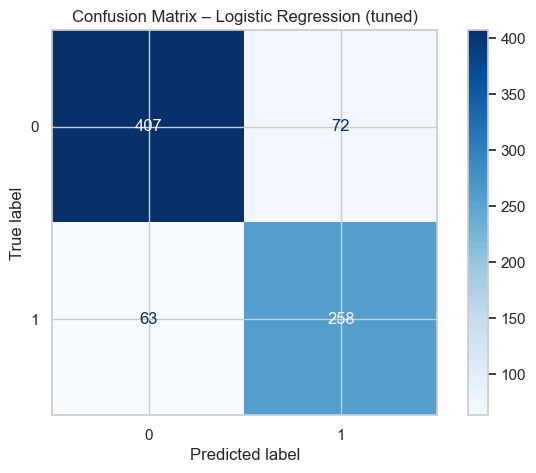

In [51]:
# === Logistic Regression ===
print("=== Logistic Regression (tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=[0, 1])
disp_log.plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression (tuned)")
plt.show()


## Cell 16 – Decision Tree: report and confusion matrix

Print the classification report and plot the confusion matrix for the tuned Decision Tree model.
We compare its accuracy and error pattern to Logistic Regression, especially for the positive class.


=== Decision Tree (tuned) ===
Accuracy: 0.77375

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.70      0.79       479
           1       0.66      0.88      0.76       321

    accuracy                           0.77       800
   macro avg       0.78      0.79      0.77       800
weighted avg       0.80      0.77      0.78       800



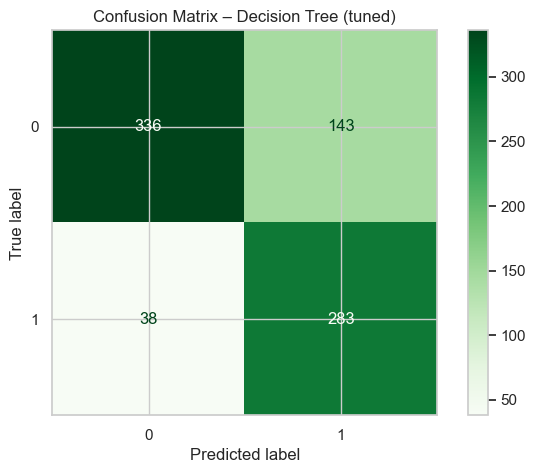

In [52]:
# === Decision Tree ===
print("=== Decision Tree (tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=[0, 1])
disp_dt.plot(cmap="Greens")
plt.title("Confusion Matrix – Decision Tree (tuned)")
plt.show()


## Cell 17 – KNN: report and confusion matrix

Print the classification report and plot the confusion matrix for the tuned KNN model.
This highlights how the instance-based approach behaves and where it differs in terms of false positives and false negatives.


=== KNN (tuned) ===
Accuracy: 0.8075

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       479
           1       0.78      0.72      0.75       321

    accuracy                           0.81       800
   macro avg       0.80      0.79      0.80       800
weighted avg       0.81      0.81      0.81       800



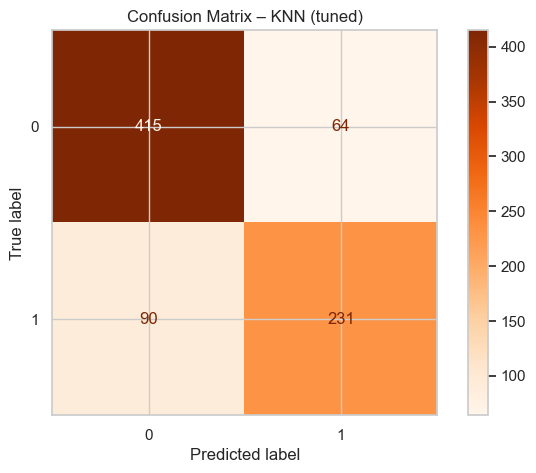

In [53]:
# === KNN ===
print("=== KNN (tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0, 1])
disp_knn.plot(cmap="Oranges")
plt.title("Confusion Matrix – KNN (tuned)")
plt.show()


## Cell 18 – ROC curve for Logistic Regression

Plot the ROC curve and compute AUC for the tuned Logistic Regression model.
This shows its ranking ability and performance across different classification thresholds.


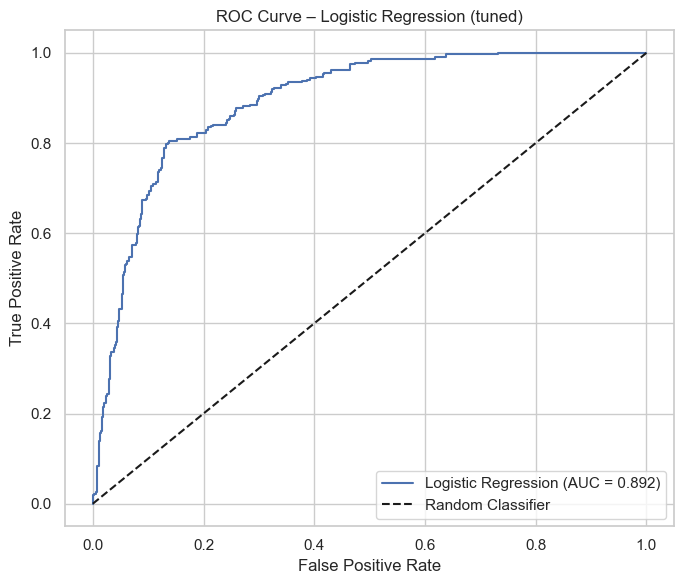

In [54]:
# ROC curve – Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_log):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression (tuned)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Cell 19 – ROC curve for Decision Tree

Plot the ROC curve and AUC for the tuned Decision Tree model.
We visually compare its curve shape and AUC to the other models.


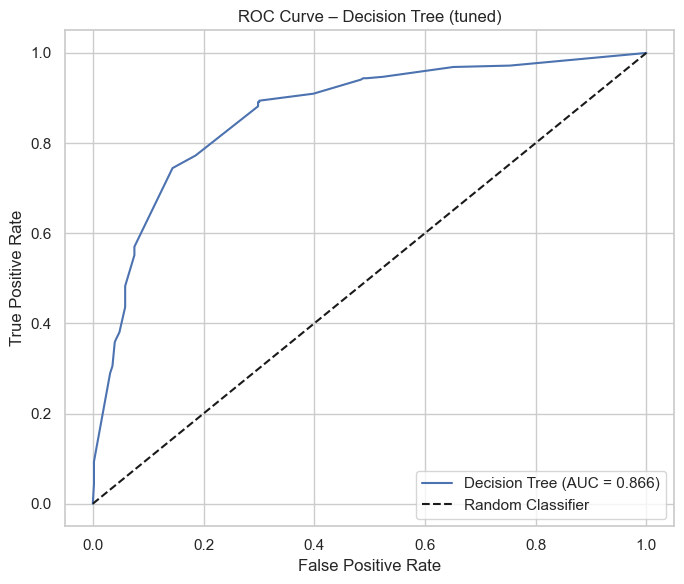

In [55]:
# ROC curve – Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

plt.figure(figsize=(7, 6))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Decision Tree (tuned)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Cell 20 – ROC curve for KNN

Plot the ROC curve and AUC for the tuned KNN model.
This completes the ROC comparison of all three tuned classifiers.


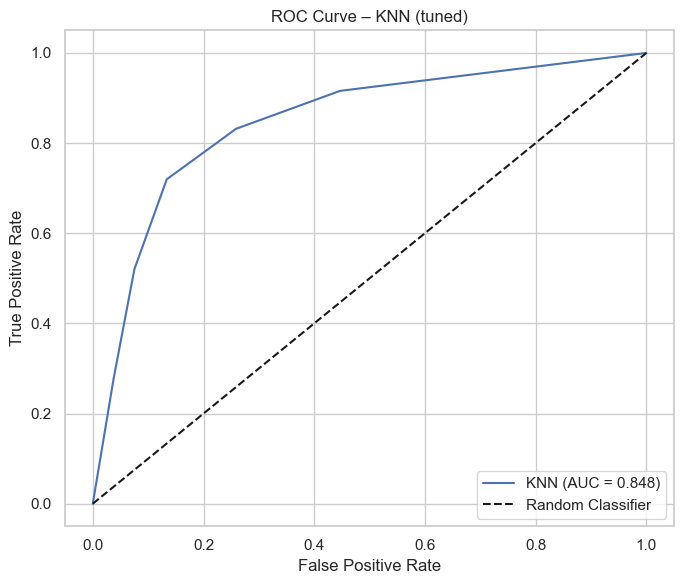

In [56]:
# ROC curve – KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_score(y_test, y_proba_knn):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN (tuned)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Cell 21 – Learning curves for tuned models

Plot learning curves (training vs validation accuracy) for each tuned model using the full dataset with artificial NaNs.
These curves help diagnose underfitting/overfitting and show how model performance changes with more training data.


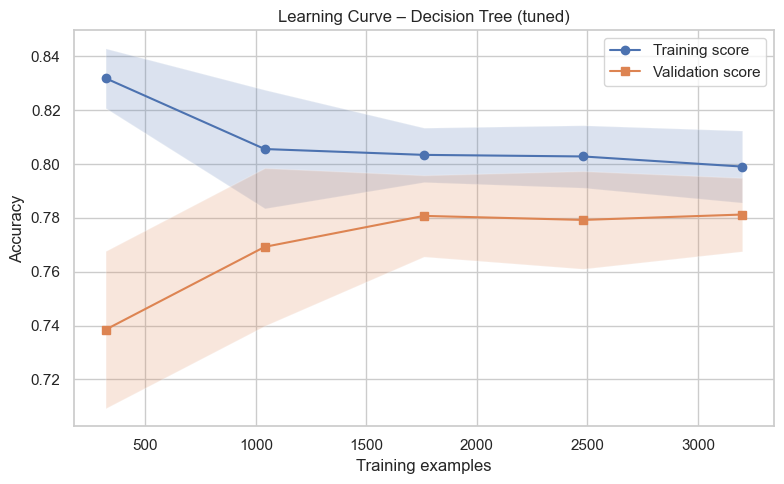

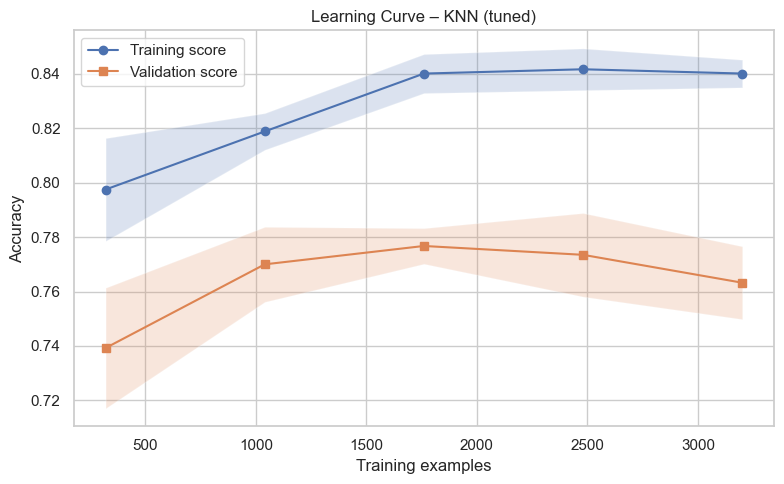

In [57]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    """
    Draws a learning curve for a given estimator (pipeline).
    X, y are the ORIGINAL features & labels (no manual scaling/encoding needed).
    """
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        train_sizes=train_sizes,
        scoring="accuracy",
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy")

    # Training scores
    plt.plot(train_sizes_abs, train_mean, marker="o", label="Training score")
    plt.fill_between(
        train_sizes_abs,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )

    # Validation scores
    plt.plot(train_sizes_abs, test_mean, marker="s", label="Validation score")
    plt.fill_between(
        train_sizes_abs,
        test_mean - test_std,
        test_mean + test_std,
        alpha=0.2
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Use the full dataset df_missing (before train/test split) for learning curves
X_full = df_missing.drop(columns=["CarInsurance", "Id"])
y_full = df_missing["CarInsurance"]

# Learning curve for tuned Logistic Regression
plot_learning_curve(
    estimator=best_log_model,
    X=X_full,
    y=y_full,
    title="Learning Curve – Logistic Regression (tuned)",
    cv=5
)

# Learning curve for tuned Decision Tree
plot_learning_curve(
    estimator=best_dt_model,
    X=X_full,
    y=y_full,
    title="Learning Curve – Decision Tree (tuned)",
    cv=5
)

# Learning curve for tuned KNN
plot_learning_curve(
    estimator=best_knn_model,
    X=X_full,
    y=y_full,
    title="Learning Curve – KNN (tuned)",
    cv=5
)


## Overall analysis and discussion

After cleaning the dataset, handling artificial and real missing values, engineering useful features, applying feature selection, and tuning hyperparameters, all three models achieve solid performance.

Using the test set results:

- **Logistic Regression (tuned)**  
  - Accuracy: **0.83125**  
  - Class 0: precision 0.87, recall 0.85  
  - Class 1: precision 0.78, recall 0.80  
  - This model gives the **best overall balance** between precision and recall on both classes.
    It correctly identifies about 80% of buyers (class 1) while keeping false positives under control.
    Macro and weighted averages around 0.83 show stable performance across classes.

- **Decision Tree (tuned)**  
  - Accuracy: **0.79125**  
  - Class 0: precision 0.85, recall 0.79  
  - Class 1: precision 0.72, recall 0.79  
  - The tree does a reasonable job, especially in recall for class 1, but its precision for buyers is lower than Logistic Regression.
    It is more flexible and interpretable, but overall slightly weaker and less stable.

- **KNN (tuned)**  
  - Accuracy: **0.79375**  
  - Class 0: precision 0.80, recall 0.88  
  - Class 1: precision 0.79, recall 0.66  
  - KNN is very good at correctly predicting non-buyers (high recall for class 0) but misses more true buyers (lower recall for class 1).
    This means it tends to produce more false negatives for the positive class.

**Conclusion:**  
For this problem, predicting whether a client will buy car insurance, the **tuned Logistic Regression** model is the most suitable choice.  
It has the highest accuracy, balanced precision/recall for the positive class, and good overall metrics.  
The cleaning, outlier handling, artificial-missing management, feature selection, and parameter tuning all contribute to reducing noise and improving the quality of the final predictions.
